In [ ]:
file = open('RNN.txt', 'r')
RNN = file.readlines()
file.close()
print(RNN)

['The future king is the prince \n', 'Daughter is the princess\n', 'Son is the prince\n', 'Only a man can be a king\n', 'Only a woman can be a queen\n', 'The princess will be a queen\n', 'The prince is a strong man\n', 'The princess is a beautiful woman\n', 'Prince is only a boy now\n', 'Prince will be king\n', 'A boy will be a man\n']


In [ ]:
for i in range(len(RNN)):
  RNN[i] = RNN[i].lower().replace('\n', '')

print(RNN)

['the future king is the prince ', 'daughter is the princess', 'son is the prince', 'only a man can be a king', 'only a woman can be a queen', 'the princess will be a queen', 'the prince is a strong man', 'the princess is a beautiful woman', 'prince is only a boy now', 'prince will be king', 'a boy will be a man']


# Remove stop words and tokenize

In [ ]:
stopwords = ['the', 'is', 'are', 'can', 'will', 'be', 'a', 'only', 'their', 'now', 'and', 'at', 'it']

filtered_data = []

for sent in RNN:
  temp = []
  for word in sent.split():
    if word not in stopwords:
      temp.append(word)
  filtered_data.append(temp)

print(filtered_data)

[['future', 'king', 'prince'], ['daughter', 'princess'], ['son', 'prince'], ['man', 'king'], ['woman', 'queen'], ['princess', 'queen'], ['prince', 'strong', 'man'], ['princess', 'beautiful', 'woman'], ['prince', 'boy'], ['prince', 'king'], ['boy', 'man']]


# Creating Bigrams

In [ ]:
bigrams = []

for word_list in filtered_data:
  for i in range(len(word_list) - 1):
    for j in range(i+1, len(word_list)):
      bigrams.append([word_list[i], word_list[j]])
      bigrams.append([word_list[j], word_list[i]])
print(bigrams)

[['future', 'king'], ['king', 'future'], ['future', 'prince'], ['prince', 'future'], ['king', 'prince'], ['prince', 'king'], ['daughter', 'princess'], ['princess', 'daughter'], ['son', 'prince'], ['prince', 'son'], ['man', 'king'], ['king', 'man'], ['woman', 'queen'], ['queen', 'woman'], ['princess', 'queen'], ['queen', 'princess'], ['prince', 'strong'], ['strong', 'prince'], ['prince', 'man'], ['man', 'prince'], ['strong', 'man'], ['man', 'strong'], ['princess', 'beautiful'], ['beautiful', 'princess'], ['princess', 'woman'], ['woman', 'princess'], ['beautiful', 'woman'], ['woman', 'beautiful'], ['prince', 'boy'], ['boy', 'prince'], ['prince', 'king'], ['king', 'prince'], ['boy', 'man'], ['man', 'boy']]


# Vocabulary

In [ ]:
all_words = []

for sent in filtered_data:
  all_words.extend(sent)

print(all_words)

all_words = list(set(all_words))
all_words.sort()

print(all_words)
print(len(all_words))

['future', 'king', 'prince', 'daughter', 'princess', 'son', 'prince', 'man', 'king', 'woman', 'queen', 'princess', 'queen', 'prince', 'strong', 'man', 'princess', 'beautiful', 'woman', 'prince', 'boy', 'prince', 'king', 'boy', 'man']
['beautiful', 'boy', 'daughter', 'future', 'king', 'man', 'prince', 'princess', 'queen', 'son', 'strong', 'woman']
12


# One-hot encoding

In [ ]:
words_dict = {}

counter = 0
for word in all_words:
  words_dict[word] = counter
  counter += 1

print(words_dict)

{'beautiful': 0, 'boy': 1, 'daughter': 2, 'future': 3, 'king': 4, 'man': 5, 'prince': 6, 'princess': 7, 'queen': 8, 'son': 9, 'strong': 10, 'woman': 11}


In [ ]:
import numpy as np
onehot_data = np.zeros((len(all_words), len(all_words)))

for i in range(len(all_words)):
  onehot_data[i][i] = 1

# print(onehot_data)

onehot_dict = {}

for i in range(len(all_words)):
  onehot_dict[all_words[i]] = onehot_data[i]

for word in onehot_dict:
  print(word, ":", onehot_dict[word])

beautiful : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
boy : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
daughter : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
future : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
king : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
man : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
prince : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
princess : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
queen : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
son : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
strong : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
woman : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
x = []
y = []

for bi in bigrams:
  x.append(onehot_dict[bi[0]])
  y.append(onehot_dict[bi[1]])

x = np.array(x)
y = np.array(y)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()

vocal_size = len(onehot_data[0])
embed_size = 2

model.add(Input(shape = (vocal_size,)))
model.add(Dense(embed_size, activation = 'linear'))
model.add(Dense(vocal_size, activation = 'softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam')

In [ ]:
model.fit(x, y, epochs = 1000)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2.4793 
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4796
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4797
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4748
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4740
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4748
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4716
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4709
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.4730
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4726
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4726
Epoch 12/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4695
Epoch 13/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4652
Epoch 14/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4620
Epoch 15/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.4631
Epo

In [28]:
weights = model.get_weights()[0]

word_embeddings = {}

for word in all_words:
  word_embeddings[word] = weights[words_dict[word]]

print(word_embeddings)

for word in all_words:
  print(word, ":", word_embeddings[word])

{'beautiful': array([-0.8739822,  1.0956666], dtype=float32), 'boy': array([ 0.6164175, -1.3770615], dtype=float32), 'daughter': array([-0.6196993 ,  0.46374524], dtype=float32), 'future': array([-0.39010078, -1.0148733 ], dtype=float32), 'king': array([ 0.24103242, -1.1054531 ], dtype=float32), 'man': array([0.82165974, 0.20238684], dtype=float32), 'prince': array([1.3329693 , 0.23102127], dtype=float32), 'princess': array([-0.8562986,  0.7550299], dtype=float32), 'queen': array([-0.74893 ,  1.198088], dtype=float32), 'son': array([-1.017161  , -0.73300695], dtype=float32), 'strong': array([ 0.2808917, -1.2804307], dtype=float32), 'woman': array([-0.8078268,  1.1805525], dtype=float32)}
beautiful : [-0.8739822  1.0956666]
boy : [ 0.6164175 -1.3770615]
daughter : [-0.6196993   0.46374524]
future : [-0.39010078 -1.0148733 ]
king : [ 0.24103242 -1.1054531 ]
man : [0.82165974 0.20238684]
prince : [1.3329693  0.23102127]
princess : [-0.8562986  0.7550299]
queen : [-0.74893   1.198088]
son 

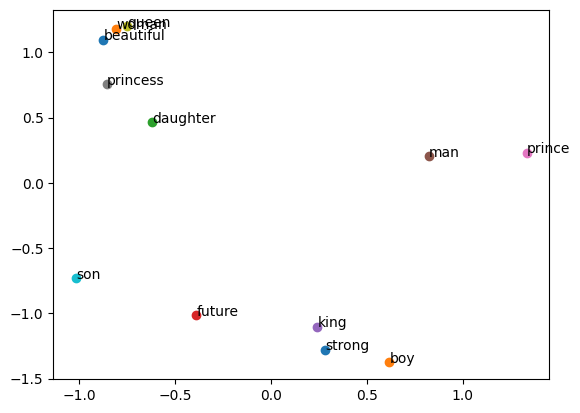

In [29]:
import matplotlib.pyplot as plt

for word in all_words:
  coordinates = word_embeddings[word]
  plt.scatter(coordinates[0], coordinates[1])
  plt.annotate(word, (coordinates[0], coordinates[1]))